# Example 1.2

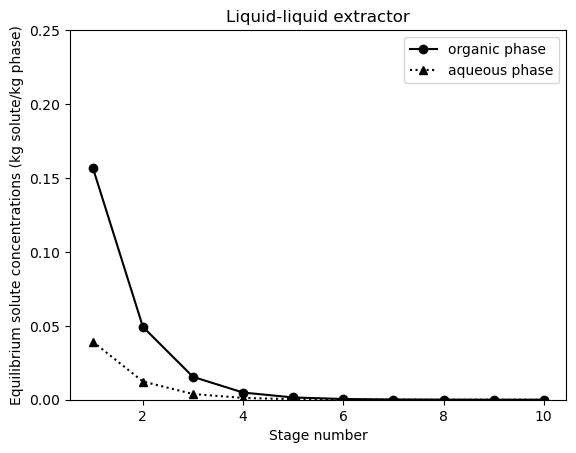

In [1]:
import numpy as np
from scipy.linalg import solve_banded
import matplotlib.pyplot as plt

# Parameters for Example 1.2
F1 = 100.0
F2 = 10.0
xin = 0.0
yin = 0.05
K = 4.0

# Common factor used in the mass balances
alpha = F2 * K / F1

# Build the right-hand side vector of the linear system
b = np.zeros((10, 1))
b[0, 0] = -yin
b[-1, 0] = -F2 * xin / F1

# Build the three diagonals of the tridiagonal linear system
# solve_banded requires the banded storage format for a tridiagonal matrix:
# ab.shape = (l+u+1, n) with (l, u) = (1, 1)
# - ab[1, :]   -> main diagonal
# - ab[0, 1:]  -> superdiagonal
# - ab[2, :-1] -> subdiagonal
e = np.ones(10)
f = -(1 + alpha) * e
g = alpha * e

# Assemble the banded matrix representation
ab = np.zeros((3, 10))
ab[1, :] = f
ab[0, 1:] = g[:-1]
ab[2, :-1] = g[:-1]

# Solution for the concentrations {y_i}
y = solve_banded((1, 1), ab, b.ravel())

# Solution for the concentrations {x_i}
x = K * y

# Plot equilibrium concentrations in each phase
eje = np.arange(1, 11)
plt.figure()
plt.plot(eje, x, 'k-o', label='organic phase')
plt.plot(eje, y, 'k:^', label='aqueous phase')
plt.title('Liquid-liquid extractor')
plt.xlabel('Stage number')
plt.ylabel('Equilibrium solute concentrations (kg solute/kg phase)')
plt.ylim([0, 0.25])
plt.legend(loc='best')
plt.show()

# Solution verification (optional)
# If A is available as the full 10x10 matrix:
# r = A @ x.reshape(-1, 1) - b